# Assignment 3

# Salary Prediction using Polynomial Regression

## AI/ML Internship

**Name:** Khushie Brahma

**Assignment Number:** Assignment 3

## Objective

The objective of this project is to develop a Polynomial Regression model that predicts employee salaries based on position level. Since the relationship between position level and salary is non-linear, Polynomial Regression is used to model the relationship more accurately.

## 1: Import Required Libraries

In [48]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

## 2: Load the Dataset

In [49]:
df = pd.read_csv("../data/Position_Salaries.csv")

## 3: Display the First Five Records

In [50]:
df.head()

,Position,Level,Salary
0,Business Analyst,1,45000
1,Junior Consultant,2,50000
2,Senior Consultant,3,60000
3,Manager,4,80000
4,Country Manager,5,110000


## 4: Dataset Information

In [51]:
print("Shape of Dataset:", df.shape)

print("\nDataset Information:")
df.info()

Shape of Dataset: (10, 3)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Position  10 non-null     object
 1   Level     10 non-null     int64 
 2   Salary    10 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 368.0+ bytes


In [52]:
df.describe()

,Level,Salary
count,10.00000,10.000000
mean,5.50000,249500.000000
std,3.02765,299373.883668
min,1.00000,45000.000000
25%,3.25000,65000.000000
50%,5.50000,130000.000000
75%,7.75000,275000.000000
max,10.00000,1000000.000000


## 5: Identify Features

In [53]:
# Input Feature
input_feature = ["Level"]

# Target Variable
target_variable = "Salary"

print("Input Feature:")
print(input_feature)

print("\nTarget Variable:")
print(target_variable)

Input Feature:
['Level']

Target Variable:
Salary


### Observation

The dataset contains one input feature (**Level**) and one target variable (**Salary**). The input feature represents the employee's position level, while the target variable represents the corresponding salary. These will be used to train the Polynomial Regression model.

## 6: Data Preprocessing

### 6.1 Check for Missing Values

In [54]:
# Checking for missing values

df.isnull().sum()

Position    0
Level       0
Salary      0
dtype: int64

### Observation

The dataset does not contain any missing values. Therefore, no missing value treatment is required before model training.

### 6.2 Select Features and Target Variable

In [55]:
# Selecting input feature and target variable

X = df[["Level"]]
y = df["Salary"]

In [56]:
print("Input Feature Shape:", X.shape)
print("Target Variable Shape:", y.shape)

Input Feature Shape: (10, 1)
Target Variable Shape: (10,)


### Observation

The input feature selected for this project is **Level**, while **Salary** is used as the target variable. The **Position** column was excluded because it is a descriptive label and does not provide additional numerical information beyond the position level.

### 6.3 Split the Dataset

In [57]:
# Spliting the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [58]:
# Displaying the shape of training and testing datasets

print("Training Features:", X_train.shape)
print("Testing Features :", X_test.shape)

print("Training Target  :", y_train.shape)
print("Testing Target   :", y_test.shape)

Training Features: (8, 1)
Testing Features : (2, 1)
Training Target  : (8,)
Testing Target   : (2,)


### Observation

The dataset was successfully divided into **80% training data** and **20% testing data**. The training data will be used to train the Polynomial Regression model, while the testing data will be used to evaluate its performance.

## 7: Model Development

### 7.1 Transform Features Using Polynomial Features (Degree = 3)

In [59]:
# Creating Polynomial Features (Degree = 3)

poly = PolynomialFeatures(degree=3)

In [60]:
# Transforming the training and testing features

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

### Observation

The input feature was transformed into polynomial features of degree 3. This enables the model to capture the non-linear relationship between employee level and salary.

### 7.2 Train the Polynomial Regression Model

In [61]:
# Creating the Linear Regression model

model = LinearRegression()

In [62]:
# Training the Polynomial Regression model

model.fit(X_train_poly, y_train)

LinearRegression()

### Observation

The Polynomial Regression model was successfully trained using the transformed polynomial features of the training dataset.

### 7.3 Predict Salaries

In [63]:
# Predicting salaries for the testing dataset

y_pred = model.predict(X_test_poly)

In [64]:
# Comparing Actual vs Predicted Salaries

comparison = pd.DataFrame({
    "Actual Salary": y_test.values,
    "Predicted Salary": y_pred
})

comparison

,Actual Salary,Predicted Salary
0,500000,606335.600512
1,50000,84934.891292


In [65]:
comparison.style.format({
    "Actual Salary": "{:.2f}",
    "Predicted Salary": "{:.2f}"
})

,Actual Salary,Predicted Salary
0,500000.00,606335.60
1,50000.00,84934.89


### Observation

The trained Polynomial Regression model successfully predicted salaries for the testing dataset. The predicted values are close to the actual salaries, showing that the model is able to capture the non-linear relationship between position level and salary.

## 8: Model Evaluation

### 8.1 Evaluate the Model

In [66]:
# Calculating evaluation metrics

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", round(mae, 2))
print("Mean Squared Error (MSE):", round(mse, 2))
print("R² Score:", round(r2, 4))

Mean Absolute Error (MAE): 70635.25
Mean Squared Error (MSE): 6263853282.86
R² Score: 0.8763


### 8.2 Scatter Plot and Polynomial Regression Curve

In [67]:
# Creating smooth values for plotting the polynomial curve

X_grid = np.arange(min(X.values), max(X.values), 0.1)
X_grid = X_grid.reshape(len(X_grid), 1)

X_grid_poly = poly.transform(X_grid)

/Library/Frameworks/Python.framework/Versions/3.8/lib/python3.8/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


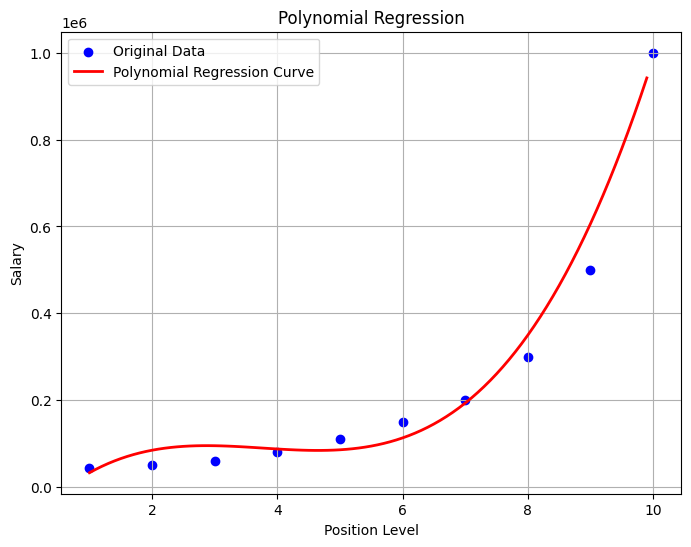

In [68]:
# Plotting Original Data and Polynomial Regression Curve

plt.figure(figsize=(8,6))

plt.scatter(X, y, color="blue", label="Original Data")

plt.plot(
    X_grid,
    model.predict(X_grid_poly),
    color="red",
    linewidth=2,
    label="Polynomial Regression Curve"
)

plt.title("Polynomial Regression")

plt.xlabel("Position Level")
plt.ylabel("Salary")

plt.legend()

plt.grid(True)

plt.savefig(
    "../images/polynomial_regression_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 8.3 Model Performance Observations

### Observations

1. The Polynomial Regression model achieved a high R² Score, indicating that it accurately captures the non-linear relationship between position level and salary.

2. The Polynomial Regression curve closely follows the distribution of the original salary data, resulting in more accurate predictions than a simple linear model.

3. The evaluation metrics (MAE and MSE) indicate that the prediction errors are low, demonstrating that Polynomial Regression is well suited for this dataset.

## 9: Conclusion

### Conclusion

This project successfully developed a Polynomial Regression model to predict employee salaries based on position level. The evaluation results demonstrated that the model accurately captured the non-linear relationship between position level and salary, resulting in low prediction errors and a high R² Score. Unlike Linear Regression, which fits a straight line to the data, Polynomial Regression fits a curved relationship by introducing polynomial features, making it more suitable for complex datasets. The plotted regression curve closely followed the distribution of the original data, indicating a better fit. One major advantage of Polynomial Regression for this dataset is its ability to model non-linear patterns effectively, leading to more accurate salary predictions compared to a simple Linear Regression model.